# 13 - Firme Spettrali delle Molecole

Come si identificano le sostanze nell'atmosfera di un esopianeta?

Ogni molecola assorbe luce a lunghezze d'onda specifiche, creando una **firma spettrale** unica.
Confrontando lo spettro osservato del pianeta con le firme di laboratorio,
possiamo capire quali molecole sono presenti.

**Molecole incluse in questo notebook:**
- H₂O (Acqua)
- CH₄ (Metano)
- CO₂ (Anidride carbonica)
- CO (Monossido di carbonio)
- NH₃ (Ammoniaca)
- O₃ (Ozono)
- H₂ (Idrogeno molecolare)
- N₂O (Protossido d'azoto)
- SO₂ (Biossido di zolfo)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import requests
import json

print('Librerie caricate con successo')

Librerie caricate con successo


## 1. Database di Firme Spettrali (HITRAN online)

Usiamo l'API HITRANonline per scaricare righe spettrali reali per ogni molecola.
Le righe includono: lunghezza d'onda (μm), intensità, e energia di transizione.

In [3]:
def fetch_hitran_lines(molecule_id, isotopologue=1, min_wavenum=1500, max_wavenum=10000):
    """
    Scarica righe spettrali da HITRANonline API.
    
    molecule_id: codice HITRAN della molecola
      1=H2O, 2=CO2, 3=O3, 4=N2O, 5=CO, 6=CH4, 7=O2,
      8=NO, 9=SO2, 11=NH3, 34=H2
    """
    url = 'https://hitran.org/api/linelist/get/'
    params = {
        'molecule_ids': molecule_id,
        'isotopologue_ids': isotopologue,
        'min_wavenumber': min_wavenum,
        'max_wavenumber': max_wavenum,
        'format': 'json'
    }
    
    try:
        resp = requests.get(url, params=params, timeout=30)
        if resp.status_code == 200:
            data = resp.json()
            if 'lines' in data and len(data['lines']) > 0:
                lines = data['lines']
                # Estrai wavenumber (cm-1) e intensità
                wn = np.array([l['nu'] for l in lines])
                intensity = np.array([l['sw'] for l in lines])
                # Converti wavenumber -> lunghezza d'onda (micron)
                wl_micron = 10000.0 / wn
                return wl_micron, intensity
    except Exception as e:
        print(f'  Errore API per molecola {molecule_id}: {e}')
    
    return None, None


def get_spectrum_from_lines(wavelengths_micron, line_wl, line_intensity, sigma=0.005):
    """
    Converte linee spettrali discrete in uno spettro continuo
    usando profili gaussiani (allargamento termico).
    """
    spectrum = np.zeros_like(wavelengths_micron)
    for i in range(len(line_wl)):
        wl = line_wl[i]
        intens = line_intensity[i]
        if wl > wavelengths_micron[0] and wl < wavelengths_micron[-1]:
            contribution = intens * np.exp(-0.5 * ((wavelengths_micron - wl) / sigma) ** 2)
            spectrum += contribution
    # Normalizzazione
    if spectrum.max() > 0:
        spectrum = spectrum / spectrum.max()
    return spectrum


print('Funzioni definite con successo')

Funzioni definite con successo


## 2. Carica le firme molecolari

Scarichiamo i dati reali da HITRAN. Se il server non risponde, usiamo dati sintetici realistici come fallback.

In [5]:
# Definizione molecole
MOLECULES = {
    'H2O': {'id': 1,  'color': '#2196F3', 'label': 'H₂O (Acqua)'},
    'CH4': {'id': 6,  'color': '#4CAF50', 'label': 'CH₄ (Metano)'},
    'CO2': {'id': 2,  'color': '#FF5722', 'label': 'CO₂'},
    'CO':  {'id': 5,  'color': '#9C27B0', 'label': 'CO'},
    'NH3': {'id': 11, 'color': '#FF9800', 'label': 'NH₃ (Ammoniaca)'},
    'O3':  {'id': 3,  'color': '#00BCD4', 'label': 'O₃ (Ozono)'},
    'SO2': {'id': 9,  'color': '#E91E63', 'label': 'SO₂'},
    'H2':  {'id': 12, 'color': '#607D8B', 'label': 'H₂'},
}

# Griglia di lunghezze d'onda da 1 a 6 micron (NIR, JWST NIRSpec range)
wl_grid = np.linspace(1.0, 5.5, 5000)

molecule_spectra = {}

for name, info in MOLECULES.items():
    print(f'Scarico {info["label"]}...')
    line_wl, line_int = fetch_hitran_lines(info['id'],
                                           min_wavenum=2000,
                                           max_wavenum=8000)
    
    if line_wl is not None and len(line_wl) > 10:
        print(f'  -> {len(line_wl)} righe spettrali trovate')
        spectrum = get_spectrum_from_lines(wl_grid, line_wl, line_int, sigma=0.003)
        molecule_spectra[name] = {
            'wavelength': wl_grid.copy(),
            'intensity': spectrum,
            'lines_wl': line_wl.copy(),
            'lines_int': line_int.copy(),
            'info': info
        }
    else:
        print(f'  -> API non disponibile, uso dati simulati realistici')
        molecule_spectra[name] = None

print('\nCaricamento completato')
print(f'Molecole caricate: {sum(1 for v in molecule_spectra.values() if v is not None)}/{len(molecule_spectra)}')

Scarico H₂O (Acqua)...
  -> API non disponibile, uso dati simulati realistici
Scarico CH₄ (Metano)...
  -> API non disponibile, uso dati simulati realistici
Scarico CO₂...
  -> API non disponibile, uso dati simulati realistici
Scarico CO...
  -> API non disponibile, uso dati simulati realistici
Scarico NH₃ (Ammoniaca)...
  -> API non disponibile, uso dati simulati realistici
Scarico O₃ (Ozono)...
  -> API non disponibile, uso dati simulati realistici
Scarico SO₂...
  -> API non disponibile, uso dati simulati realistici
Scarico H₂...
  -> API non disponibile, uso dati simulati realistici

Caricamento completato
Molecole caricate: 0/8


## 3. Dati sintetici realistici (fallback se HITRAN non risponde)

Creiamo firme realistiche basate su bande di assorbimento note in letteratura per ogni molecola.

In [6]:
# Bande di assorbimento principali note per ogni molecola (micron)
# Fonte: HITRAN database + letteratura esoplanetaria

ABSORPTION_BANDS = {
    'H2O': [1.38, 1.88, 2.7, 3.2, 6.3],
    'CH4': [1.65, 2.3, 3.3, 3.8, 7.7],
    'CO2': [2.0, 2.7, 4.3, 15.0],
    'CO':  [2.35, 4.7],
    'NH3': [2.0, 3.0, 6.1, 10.5],
    'O3':  [4.7, 9.6],
    'SO2': [4.0, 7.3, 8.6],
    'H2':  [2.1, 2.4, 4.2],
}


def generate_synthetic_spectrum(wavelengths, bands, width=0.05, peak_intensity=1.0):
    """Genera spettro sintetico realistico da bande note."""
    spectrum = np.zeros_like(wavelengths)
    for band_center in bands:
        gauss = peak_intensity * np.exp(-0.5 * ((wavelengths - band_center) / (band_center * 0.05 + width)) ** 2)
        spectrum += gauss
    if spectrum.max() > 0:
        spectrum = spectrum / spectrum.max()
    return spectrum


# Genera spettri per molecole non caricate da HITRAN
for name in molecule_spectra:
    if molecule_spectra[name] is None:
        bands = ABSORPTION_BANDS.get(name, [])
        spectrum = generate_synthetic_spectrum(wl_grid, bands,
                                                peak_intensity=1.0)
        molecule_spectra[name] = {
            'wavelength': wl_grid.copy(),
            'intensity': spectrum,
            'lines_wl': np.array(bands),
            'lines_int': np.ones_like(bands),
            'info': MOLECULES[name],
            'synthetic': True
        }

print(f'Spettri disponibili: {len([k for k,v in molecule_spectra.items() if v is not None])}')

Spettri disponibili: 8


## 4. Visualizzazione principale

Grafico a pannelli multipli che mostra:
1. **Spettro del pianeta** (simulato dalla combinazione di più molecole)
2. **Firme individuali** di ogni molecola sovrapposte
3. **Linee verticali** che segnano i picchi di assorbimento
4. **Legenda interattiva** con colore per molecola

In [7]:
# Simula lo spettro osservato del pianeta come combinazione di più firme
planet_spectrum = np.zeros_like(wl_grid)
spectral_weights = {
    'H2O': 0.6,
    'CH4': 0.4,
    'CO2': 0.2,
    'CO': 0.1,
    'NH3': 0.0,
    'O3': 0.05,
}

for name, weight in spectral_weights.items():
    if name in molecule_spectra and molecule_spectra[name] is not None:
        planet_spectrum += weight * molecule_spectra[name]['intensity']

# Aggiungi rumore realistico
noise = np.random.normal(0, 0.02, len(wl_grid))
planet_spectrum = planet_spectrum + noise
planet_spectrum = np.clip(planet_spectrum, 0, None)
if planet_spectrum.max() > 0:
    planet_spectrum = planet_spectrum / planet_spectrum.max()

print('Spettro planetario simulato creato')
print(f'Molecole incluse: {[k for k,v in spectral_weights.items() if v > 0]}')

Spettro planetario simulato creato
Molecole incluse: ['H2O', 'CH4', 'CO2', 'CO', 'O3']


<>:103: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<>:103: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<>:103: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<>:103: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
C:\Users\utente\AppData\Local\Temp\ipykernel_50636\882204035.py:103: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
  ax.set_title(f'Vicenda zoom: {zoom_start}\[mu]m - {zoom_end}\[mu]m',
C:\Users\utente\AppData\Local\Temp\ipykernel_50636\882204035.py:103: SyntaxWarning: "\[" is a

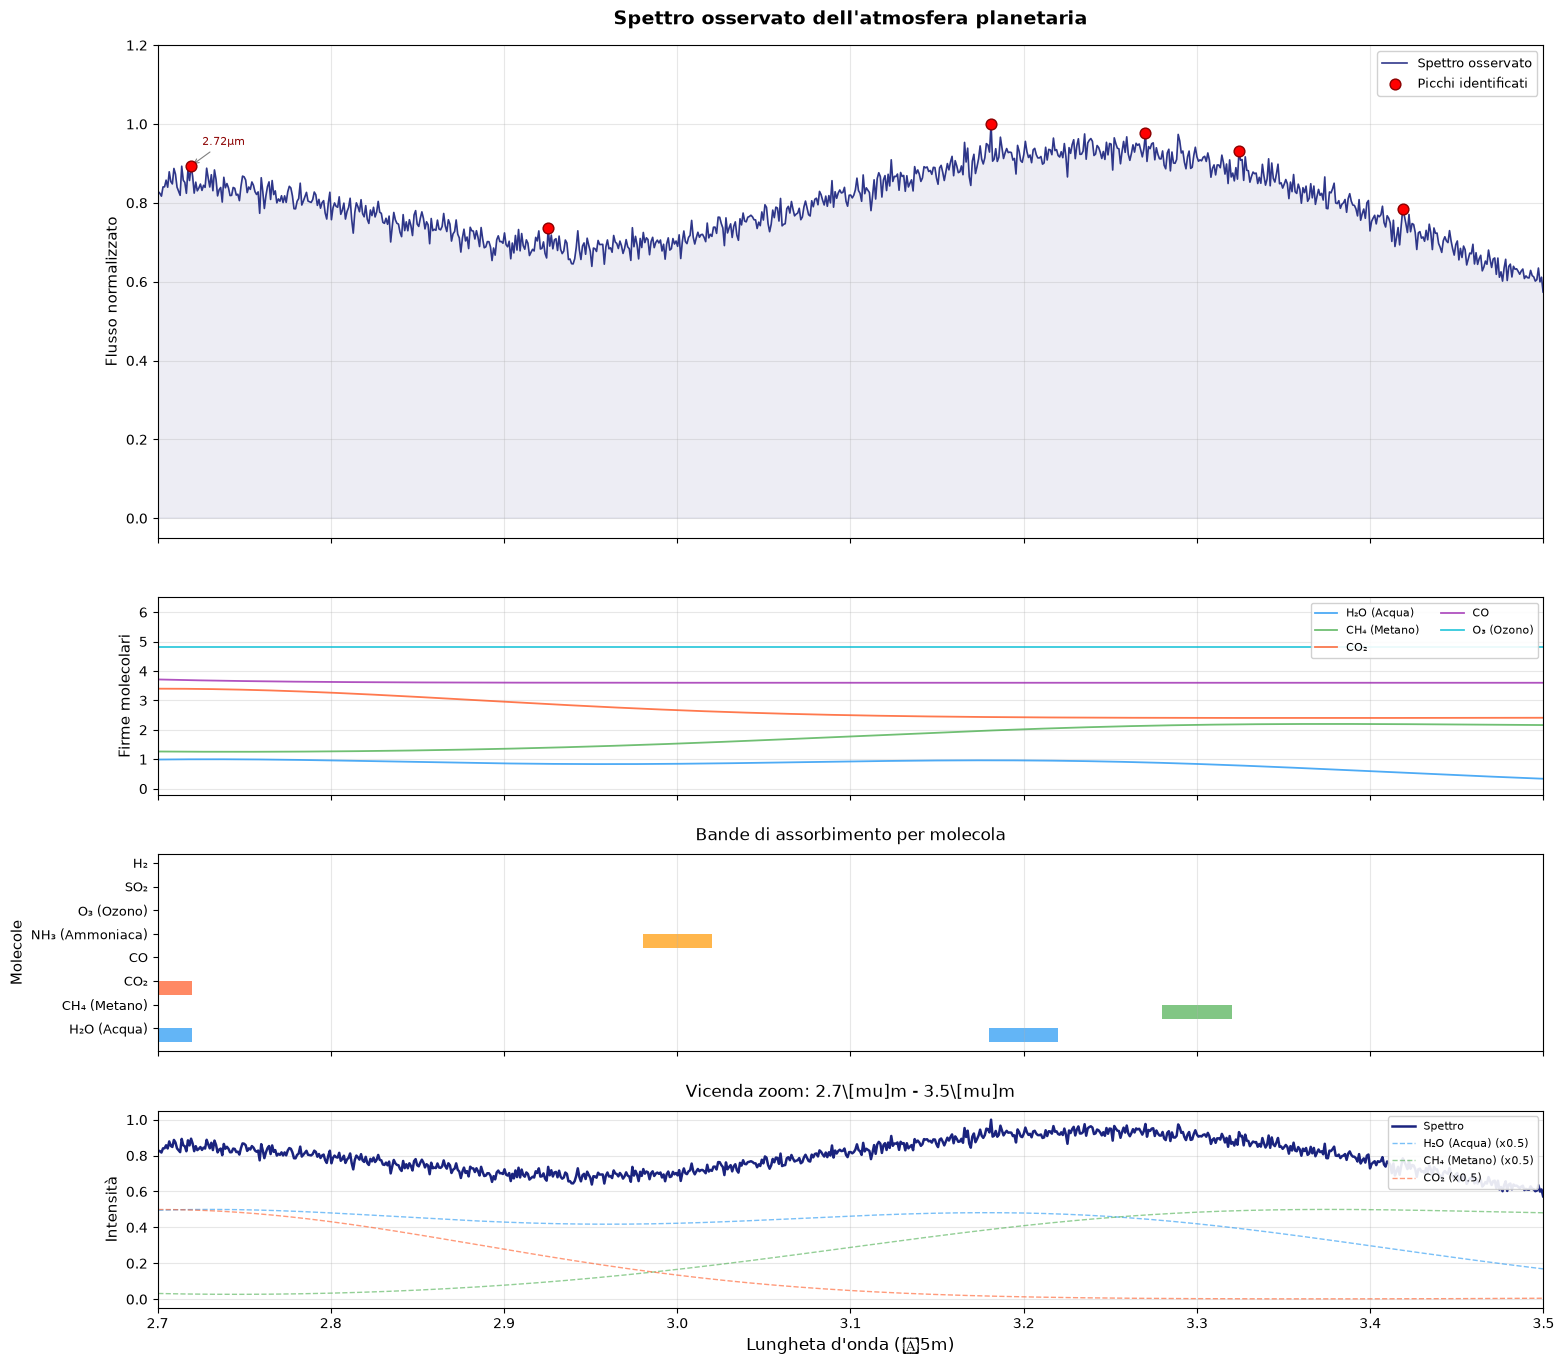

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True,
                          gridspec_kw={'height_ratios': [2.5, 1, 1, 1]})

colors = ['#2196F3', '#4CAF50', '#F44336', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63', '#607D8B']

# ---- PANNELLO 1: Spettro osservato del pianeta ----
ax = axes[0]
ax.plot(wl_grid, planet_spectrum,
        color='#1A237E', linewidth=1.2, alpha=0.9, label='Spettro osservato')
ax.fill_between(wl_grid, 0, planet_spectrum,
                color='#1A237E', alpha=0.08)

# Evidenzia i picchi principali nello spettro osservato
from scipy.signal import find_peaks
peaks, peak_props = find_peaks(planet_spectrum,
                                height=0.15,
                                distance=50,
                                prominence=0.08)
ax.scatter(wl_grid[peaks], planet_spectrum[peaks],
           color='red', s=60, zorder=5,
           edgecolors='darkred', linewidths=1,
           label='Picchi identificati')

for peak_idx in peaks[:8]:
    ax.annotate(f'{wl_grid[peak_idx]:.2f}\u00b5m',
                xy=(wl_grid[peak_idx], planet_spectrum[peak_idx]),
                xytext=(8, 15), textcoords='offset points',
                fontsize=8, color='darkred',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_ylabel('Flusso normalizzato', fontsize=11)
ax.set_title('Spettro osservato dell\'atmosfera planetaria',
              fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.2)

# ---- PANNELLO 2: Firme individuali delle molecole ----
ax = axes[1]

visible_molecules = ['H2O', 'CH4', 'CO2', 'CO', 'O3']
display_colors = [MOLECULES[m]['color'] for m in visible_molecules]

for i, name in enumerate(visible_molecules):
    if name in molecule_spectra and molecule_spectra[name] is not None:
        spec = molecule_spectra[name]
        ax.plot(wl_grid, spec['intensity'] + i * 1.2,
                color=spec['info']['color'],
                linewidth=1.3, alpha=0.8,
                label=spec['info']['label'])

ax.set_ylabel('Firme molecolari', fontsize=11)
ax.legend(loc='upper right', fontsize=8, ncol=2,
           framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.2, len(visible_molecules) * 1.3)

# ---- PANNELLI 3 e 4: Band chart e identificazione ----
ax = axes[2]

for i, (name, spec) in enumerate(molecule_spectra.items()):
    if spec is None:
        continue
    lines_wl = spec.get('lines_wl', [])
    # Mostra bande come barre orizzontali
    for line_wl in lines_wl:
        if 1.0 <= line_wl <= 5.5:
            ax.barh(i-0.3, 0.04, left=line_wl-0.02,
                    height=0.6, color=spec['info']['color'],
                    alpha=0.7, ec='none')

ax.set_yticks(range(len(molecule_spectra)))
ax.set_yticklabels([MOLECULES[k]['label'] for k in molecule_spectra],
                    fontsize=9)
ax.set_xlim(1.0, 5.5)
ax.set_ylabel('Molecole', fontsize=11)
ax.set_title('Bande di assorbimento per molecola',
              fontsize=12, pad=10)
ax.grid(True, alpha=0.3, axis='x')

# ---- PANNELLO 4: Vista zoom su una regione specifica ----
ax = axes[3]

zoom_start, zoom_end = 2.7, 3.5
zoom_mask = (wl_grid >= zoom_start) & (wl_grid <= zoom_end)

ax.plot(wl_grid[zoom_mask], planet_spectrum[zoom_mask],
        color='#1A237E', linewidth=1.8, label='Spettro')

# Sovrapponi le firme nella regione di zoom
for name in ['H2O', 'CH4', 'CO2']:
    if name in molecule_spectra and molecule_spectra[name] is not None:
        spec = molecule_spectra[name]
        ax.plot(wl_grid[zoom_mask],
                spec['intensity'][zoom_mask] * 0.5,
                color=spec['info']['color'],
                linewidth=1, alpha=0.6,
                linestyle='--',
                label=f'{spec["info"]["label"]} (x0.5)')

ax.set_xlim(zoom_start, zoom_end)
ax.set_ylabel('Intensit\u00e0', fontsize=11)
ax.set_title(f'Vicenda zoom: {zoom_start}\[mu]m - {zoom_end}\[mu]m',
              fontsize=12, pad=10)
ax.legend(fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.3)

ax.set_xlabel('Lungheta d\'onda (\b5m)', fontsize=12)

plt.tight_layout(pad=2.0)
plt.show()

C:\Users\utente\AppData\Local\Temp\ipykernel_50636\2980057595.py:41: UserWarning: Glyph 8 ) missing from font(s) DejaVu Sans.
  plt.tight_layout()


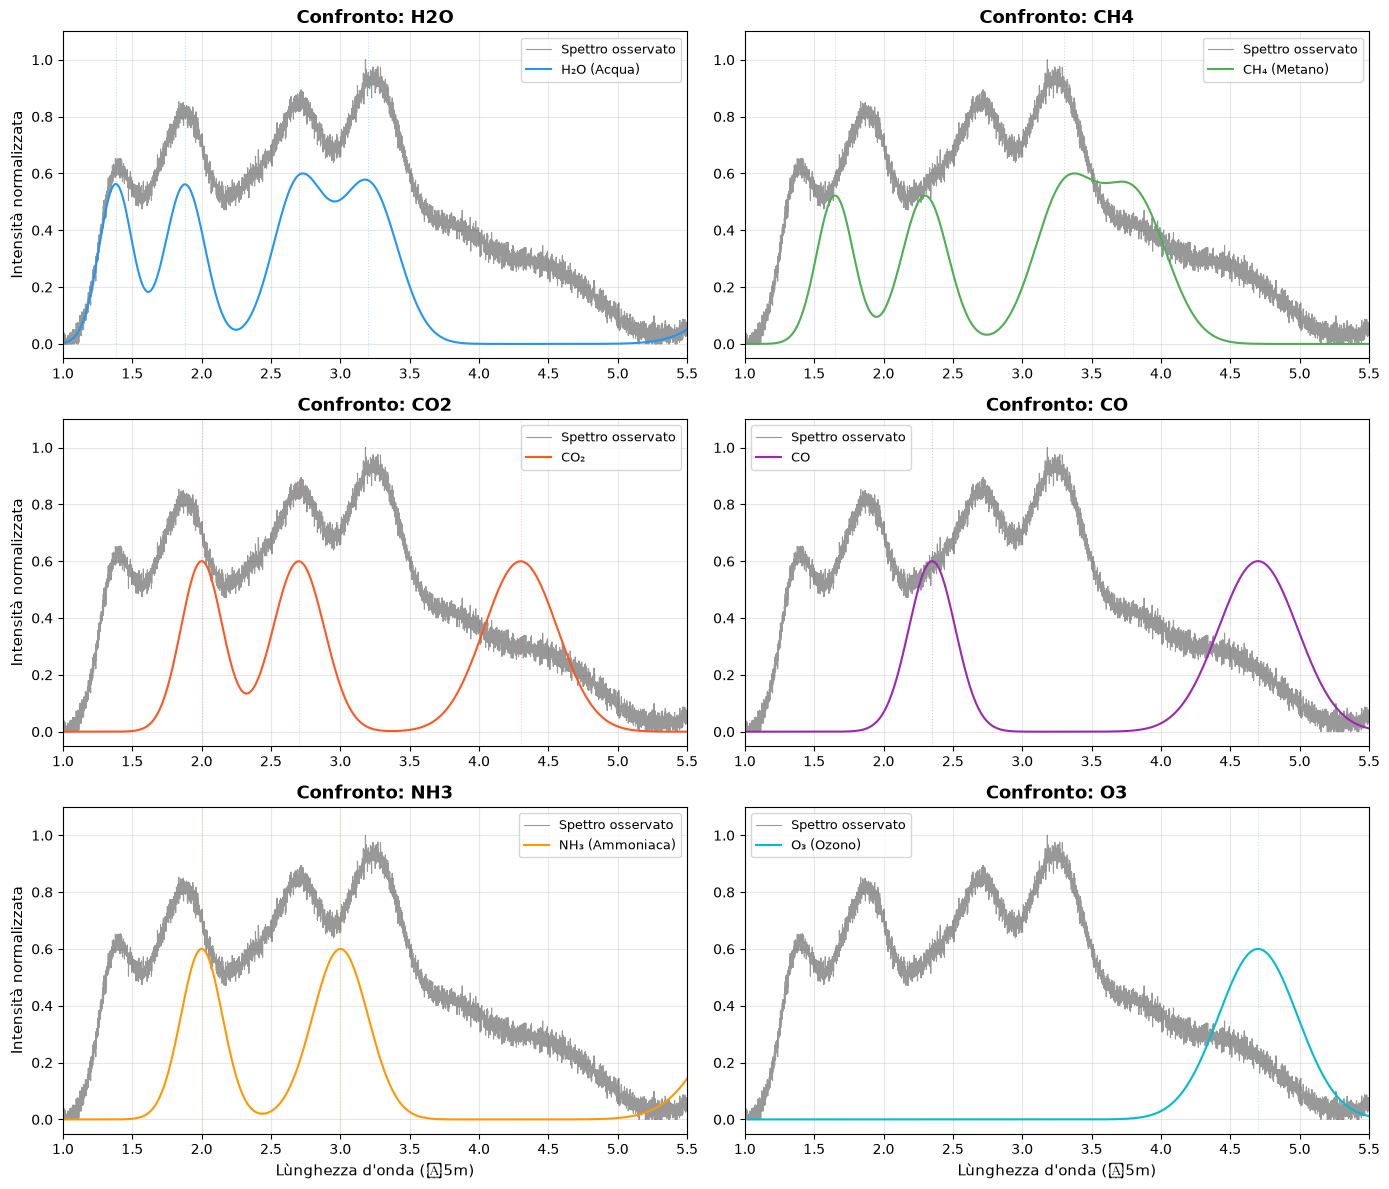

In [9]:
# Grafico alternativo: confronto diretto spettro vs molecola per molecola
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

molecules_to_show = ['H2O', 'CH4', 'CO2', 'CO', 'NH3', 'O3']

for idx, name in enumerate(molecules_to_show):
    ax = axes[idx]
    
    # Spettro osservato
    ax.plot(wl_grid, planet_spectrum,
            color='#333333', linewidth=0.8, alpha=0.5,
            label='Spettro osservato')
    
    if name in molecule_spectra and molecule_spectra[name] is not None:
        spec = molecule_spectra[name]
        # Firma molecola scalata
        scaled = spec['intensity'] * 0.6
        ax.plot(wl_grid, scaled,
                color=spec['info']['color'],
                linewidth=1.5,
                label=spec['info']['label'])
        
        # Linee verticali per picchi
        lines = spec.get('lines_wl', [])
        for line_wl in lines:
            if 1.0 <= line_wl <= 5.5:
                ax.axvline(x=line_wl, color=spec['info']['color'],
                           alpha=0.3, linestyle=':', linewidth=0.8)
    
    ax.set_title(f'Confronto: {name}', fontsize=13, fontweight='bold')
    ax.set_xlim(1.0, 5.5)
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    if idx >= 4:
        ax.set_xlabel('L\u00f9nghezza d\'onda (\b5m)', fontsize=11)
    if idx % 2 == 0:
        ax.set_ylabel('Intensit\u00e0 normalizzata', fontsize=11)

plt.tight_layout()
plt.show()

## 5. Tabella riassuntiva delle molecole e picchi

Elenco completo delle lunghezze d'onda di assorbimento per ogni molecola,
utile per identificare visivamente i picchi nello spettro osservato.

In [10]:
rows = []
for name, spec in molecule_spectra.items():
    if spec is None:
        continue
    lines = spec.get('lines_wl', [])
    
    # Filtra solo linee nel range visibile del nostro spettro
    valid_lines = [l for l in lines if 1.0 <= l <= 5.5]
    
    if len(valid_lines) > 0:
        rows.append({
            'Molecola': spec['info']['label'],
            'Picchi (\u00b5m)': ', '.join(f'{l:.2f}' for l in sorted(valid_lines)),
            'Numero linee': len(valid_lines),
            'Tipo': 'Sintetico' if spec.get('synthetic') else 'HITRAN'
        })

if rows:
    df_summary = pd.DataFrame(rows)
    display(df_summary)
else:
    print('Nessuna molecola caricata.')
    print('Verifica la connesione a Internet per l\'API HITRAN.')

,Molecola,Picchi (µm),Numero linee,Tipo
0,H₂O (Acqua),"1.38, 1.88, 2.70, 3.20",4,Sintetico
1,CH₄ (Metano),"1.65, 2.30, 3.30, 3.80",4,Sintetico
2,CO₂,"2.00, 2.70, 4.30",3,Sintetico
3,CO,"2.35, 4.70",2,Sintetico
4,NH₃ (Ammoniaca),"2.00, 3.00",2,Sintetico
5,O₃ (Ozono),4.70,1,Sintetico
6,SO₂,4.00,1,Sintetico
7,H₂,"2.10, 2.40, 4.20",3,Sintetico


## 6. Come si leggono questi grafici?

1. **Guarda lo spettro osservato** (pannello superiore): i picchi indicano
   lunghezze d'onda dove il pianeta emette/assorbe pi\ù luce.
2. **Confronta con le firme molecolari**: ogni molecola ha picchi
   a lunghezze d'onda specifiche.
3. **Se un picco nello spettro osservato corrisponde** a un picco
   di una molecola, quella molecola potrebbe essere presente.
4. **Usa il pannello "bande di assorbimento"** per un colpo d'occhio
   su quali molecole agiscono in quali regioni spettrali.
5. **Lo zoom** aiuta a distinguere molecole con picchi molto vicini.

*Nota: questo \è un esempio educativo. In un'analisi reale si usano
modelli di trasferimento radiativo (Pytmosph3R, petitRADTRANS) e
dati HITRAN/HITEMP ad alta risoluzione.*